In [ ]:
import micropattern as mic
from pathlib import Path
import scanpy as sc
import pandas as pd
import esfs
import numpy as np

sc.set_figure_params(figsize=(5, 5))
cwd = Path(".").resolve()
print(cwd)

/home/stanfish/Git/micropattern/notebooks


In [2]:
mic.io.fetch_heemskerk(cwd)

100%|██████████| 4/4 [02:13<00:00, 33.46s/it]


In [ ]:
adata_heemskerk_D2_D10 = mic.io.HEEMSKERK_ADATA_D2_D10["adata"]
meta_heemskerk_D2_D10 = mic.io.HEEMSKERK_ADATA_D2_D10["meta"]
adata_heemskerk_42h = mic.io.HEEMSKERK_ADATA_42H
heemskerk_data_path = cwd / "heemskerk_data"
adata_heemskerk_d2_d10 = sc.read_h5ad(heemskerk_data_path / adata_heemskerk_D2_D10)
meta_heemskerk_d2_d10 = pd.read_csv(
    heemskerk_data_path / meta_heemskerk_D2_D10, index_col=0
)
adata_heemskerk_d2_d10.obs = meta_heemskerk_d2_d10.loc[adata_heemskerk_d2_d10.obs.index]
adata_heemskerk_42h_list = []
for s, f in adata_heemskerk_42h.items():
    adata_tmp = sc.read_h5ad(heemskerk_data_path / f)
    adata_tmp.obs["sample_labels"] = adata_tmp.obs["sample_labels"].str.cat(
        ["_42h"] * adata_tmp.shape[0]
    )
    adata_heemskerk_42h_list.append(adata_tmp)
adata_heemskerk_42h = sc.concat(adata_heemskerk_42h_list)
print(adata_heemskerk_d2_d10)
print(adata_heemskerk_42h)

AnnData object with n_obs × n_vars = 62402 × 16519
    obs: 'sample_labels', 'leiden_sub', 'leiden_sub_sub2', 'branch_joint', 'dpt_pseudotime', 'leiden_sub_colors', 'leiden_sub_sub2_colors', 'umap_old_48-96h_x', 'umap_old_48-96h_y', 'umap_new_D4-10_x', 'umap_new_D4-10_y'
AnnData object with n_obs × n_vars = 10815 × 20685
    obs: 'sample_labels'


In [ ]:
adata_heemskerk_72h = adata_heemskerk_d2_d10[
    adata_heemskerk_d2_d10.obs["sample_labels"].str.contains("72h-1")
].copy()
adata_heemskerk_72h.obsm["X_umap"] = np.array(
    adata_heemskerk_72h.obs.loc[:, ["umap_old_48-96h_x", "umap_old_48-96h_y"]]
)

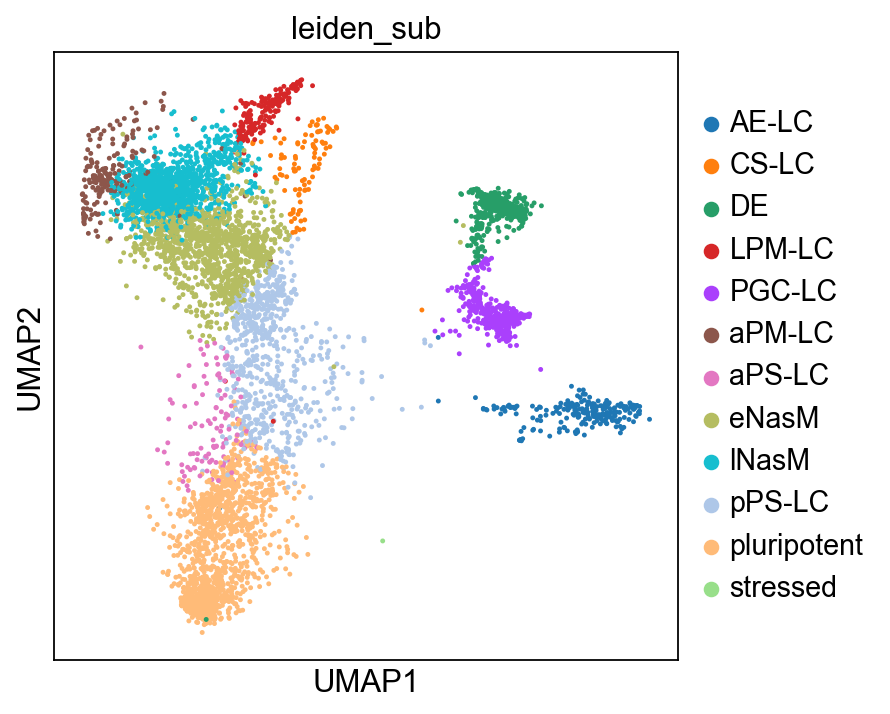

In [16]:
sc.pl.umap(adata_heemskerk_72h, color="leiden_sub")

Pruning ESS graph by removing genes with with low numbers of edges (min_edges = 5)
Starting genes = 13821
Remaining genes = 9376
Remaining genes = 9282
Remaining genes = 9262
Remaining genes = 9251
Remaining genes = 9242
Remaining genes = 9235
Calculating feature weights
Known inportant gene ranks:
      SOX2 (ENSG00000181449)  TBXT (ENSG00000164458)
Rank                     796                    1604
ESFS gene weights have been saved to 'adata.var['ESFS_Gene_Weights']'
ESFS gene ranks have been saved to 'adata.var['ES_Rank']'
Visualising the ESS graph of the top 1000 ranked genes in a UMAP.
Clustering == an integer value leading to Kmeans clustering, set Clustering to 'hdbscan' for automated density clustering.
This function outputs the 'Top_ESS_Genes', 'Gene_Clust_Labels' and 'Gene_Embedding' objects in case users would like to investigate them further.


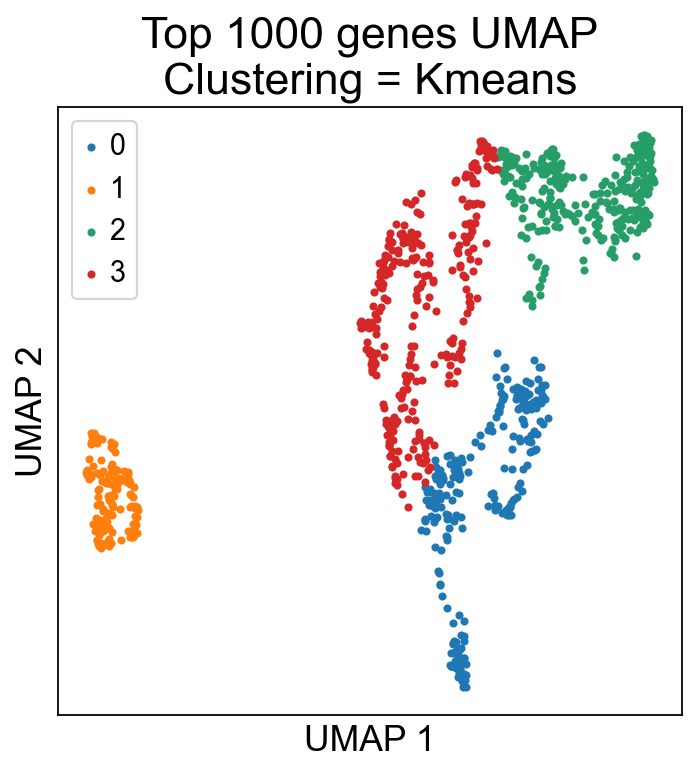

In [ ]:
print(adata_heemskerk_72h)
esfs.configure(gpu=False)
adata_heemskerk_72h = esfs.create_scaled_matrix(
    adata_heemskerk_72h, clip_percentile=97.5
)
adata_heemskerk_72h = esfs.parallel_calc_es_matrices(
    adata_heemskerk_72h,
    secondary_features_label="Self",
    save_matrices=np.array(["ESSs", "EPs"]),
)
adata_heemskerk_72h = esfs.ES_rank_genes(
    adata_heemskerk_72h,
    min_edges=5,
    known_important_genes=adata_heemskerk_72h.var_names[
        adata_heemskerk_72h.var_names.str.contains("^SOX2 |TBXT")
    ],
)
top_genes, labels, embedding = esfs.plot_top_ranked_genes_UMAP(
    adata_heemskerk_72h, top_ranked_genes=1000, clustering=4
)

In [57]:
adata_heemskerk_72h.layers["counts"] = adata_heemskerk_72h.X.copy()

In [66]:
adata_heemskerk_72h.obs["leiden_sub"].value_counts()

leiden_sub
lNasM          1399
pluripotent    1357
eNasM          1146
pPS-LC          661
PGC-LC          406
DE              388
AE-LC           236
aPM-LC          187
LPM-LC          174
aPS-LC          114
CS-LC            97
stressed          1
Name: count, dtype: int64

In [ ]:
sc.pp.highly_variable_genes(
    adata_heemskerk_72h,
    n_top_genes=1000,
    flavor="seurat_v3",
    subset=False,
    layer="counts",
)

In [62]:
adata_heemskerk_72h.var

,ESFS_Gene_Weights,ES_Rank,highly_variable,highly_variable_rank,means,variances,variances_norm
A2ML1 (ENSG00000166535),NaN,NaN,False,NaN,0.029030,0.032085,0.926029
A4GALT (ENSG00000128274),NaN,NaN,False,NaN,0.048816,0.056173,0.953133
AAAS (ENSG00000094914),0.000022,6680.0,False,NaN,0.951346,1.120422,0.840252
AACS (ENSG00000081760),0.000016,7981.0,False,NaN,0.642232,0.826077,0.991562
AADAT (ENSG00000109576),0.000054,2841.0,False,NaN,0.238080,0.270316,0.935119
...,...,...,...,...,...,...,...
ZXDC (ENSG00000070476),NaN,NaN,False,NaN,0.168829,0.181873,0.900310
ZYG11A (ENSG00000203995),NaN,NaN,False,NaN,0.029679,0.032696,0.921936
ZYG11B (ENSG00000162378),0.000024,6333.0,False,NaN,0.673857,0.833273,0.945955
ZYX (ENSG00000159840),0.000033,4478.0,False,NaN,1.311061,1.915878,0.972773


In [67]:
# white list genes made by Idse before
coremarkers = ["SOX2", "TBXT", "SOX17", "ISL1"]
epiblast = [
    "PODXL",
    "SOX2",
    "NANOG",
    "POU5F1",
    "KLF4",
    "OTX2",
    "ESRG",
    "DPPA4",
    "USP44",
]
streak = ["TBXT", "MIXL1", "EOMES"]
mesoderm = [
    "GSC",
    "TBX6",
    "MESP1",
    "GATA6",
    "GATA4",
    "MSGN1",
    "PDGFRA",
    "EPHA4",
    "ZIC3",
    "LHX1",
    "DLL3",
    "RSPO3",
    "FOXC1",
    "FOXF1",
]  # ,'EPHA4','ZIC3' Zhou..Lanner..Chien embryonic mesoderm
endoderm = [
    "OTX2",
    "PRDM1",
    "SOX17",
    "FOXA2",
    "HHEX",
    "LHX1",
    "TTR",
    "GATA4",
    "KIT",
    "CXCR4",
]
ectoderm = ["SOX1", "SOX2", "SOX3", "NES"]
TE = ["CGA", "XAGE3", "PGF", "WNT3A"]
amnion = [
    "ISL1",
    "BMP4",
    "GABRP",
    "HEY1",
    "LYPD1",
    "WNT6",
]  # ,'WFDC2','ANXA3','CDO1'] #Zhou..Lanner...
sexmeso = ["PITX1", "TBX4", "CYB5A", "MLLT3", "ALCAM"]  # Zhou..Lanner...
ysmeso = ["ETS1", "ANXA1", "POSTN", "DCN"]
exMC = ["VIM", "COL3A1", "HGF", "COL6A2", "HAND2", "COL1A1", "POSTN"]
extraembryonic = (
    [
        "CDX2",
        "GATA2",
        "GATA3",
        "HAND1",
        "TBX3",
        "TFAP2A",
        "DLX5",
        "KRT18",
        "KRT7",
        "TP63",
    ]
    + TE
    + amnion
    + sexmeso
    + ysmeso
    + exMC
)
PGC = [
    "PRDM1",
    "SOX17",
    "TFAP2C",
    "NANOG",
    "ALPP",
    "DPPA4",
    "NANOS3",
    "LAMA4",
    "KLF4",
    "KIT",
    "CXCR4",
    "DDX4",
    "DAZL",
    "DPPA3",
]  # DDX4=VASA, DPPA3=stella
endothelium = ["PECAM1", "MEF2C"]
blood = ["RUNX1", "GATA1", "HBE1"]
heart = ["NKX2-5", "MESP1", "TBX1", "TBX5", "ISL1", "TNNT2"]
lung = ["NKX2-1"]
organs = endothelium + blood + heart + lung
HOX = ["HOX[ABCD][1-9]+"]
germmarkers = list(
    np.unique(epiblast + mesoderm + endoderm + ectoderm + extraembryonic + PGC)
)
allmarkers = list(np.unique(germmarkers + organs + HOX))
coreligands = [
    "DKK[1-9]",
    "LEFTY[1-2]",
    "NODAL",
    "WNT3",
    "WNT3A",
    "WNT6",
    "WNT5A",
    "WNT5B",
    "WNT8A",
    "BMP2",
    "BMP4",
    "BMP7",
    "CER1",
    "NOG",
    "FGF2",
    "FGF4",
    "FGF8",
    "FGF17",
]
TGFbtransduction = ["SMAD[1-9]", "ACVR[1-2][ABC]*", "BMPR[1-2][ABC]*", "TGFBR", "TDGF1"]
wnt = ["WNT[1-9]+[AB]*", "RSPO[1-9]", "FZD[1-9]*", "DVL"]
othersignaling = ["EGF", "EGFR"]
FGFR = ["FGFR[1-4]"]
extracell_FGFact = ["KL", "GLG1", "FLRT", "KAL1"]  # klotho, cfr, flrt, anosmin-1
extracell_FGFinh = ["FGFRL1", "IL17RD"]  # FGFRL1, SEF
intracell_ERKinh = ["SPRY[1-4]", "DUSP[1-9]", "DUSP10", "DUSP14", "DUSP26", "PEBP1"]
intracell_ERKact = [
    "MAP2K[1-2]",
    "MAPK3",
    "MAPK1",
    "ARAF",
    "BRAF",
    "RAF1",
]  # K3 = ERK1, #K1 = ERK2, MEK1/2 are phosporylated by RAS
HSPG_synthesis = [
    "EXT1",
    "EXT2",
    "UGDH",
]  # EXT catalyze HS side chain elongation, UGDH : Garcia-Garcia & Anderson, makes side chains
HSPG = [
    "HSPG2",
    "AGRIN",
    "SDC[1-4]",
    "GPC[1-9]",
]  # HSPG2: perlecan (secreted), agrin=secreted, syndecan=transmembrane, glypican (GPI-anchored)
HSPG_desulf = ["SULF"]  # 6-O sulfatases - inhibit FGF
HSPG_shedding = ["HPSE", "HTRA1"]  # heparanase
HSPG_sulfotransferase = ["HS6ST", "HS2ST", "HS3ST", "NDST"]
FGF_inhibition = HSPG_desulf + extracell_FGFinh + intracell_ERKinh
FGF_activation = (
    FGFR
    + extracell_FGFact
    + HSPG_synthesis
    + HSPG
    + HSPG_shedding
    + HSPG_sulfotransferase
    + intracell_ERKact
)
FGF_modulation = FGF_inhibition + FGF_activation
allsignaling = coreligands + TGFbtransduction + FGF_modulation + wnt + othersignaling
EMT = ["CDH[1-2]", "VIM", "EPCAM", "SNAI[1-2]", "PAI[1-3]"]
allgenes = list(np.unique(allmarkers + EMT + allsignaling))
allgenes_re_symbol = list(np.unique(allmarkers + EMT + allsignaling))
allgenes = ["^" + g + "($| )" for g in allgenes]

/tmp/ipykernel_103126/3449712520.py:24: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  adata_heemskerk_72h.var_names.str.contains(pattern, regex=True)
/tmp/ipykernel_103126/3449712520.py:24: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  adata_heemskerk_72h.var_names.str.contains(pattern, regex=True)
/tmp/ipykernel_103126/3449712520.py:24: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  adata_heemskerk_72h.var_names.str.contains(pattern, regex=True)
/tmp/ipykernel_103126/3449712520.py:24: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  adata_heemskerk_72h.var_names.str.contains(pattern, regex=True)
/tmp/ipykernel_103126/3449712520.py:24: User

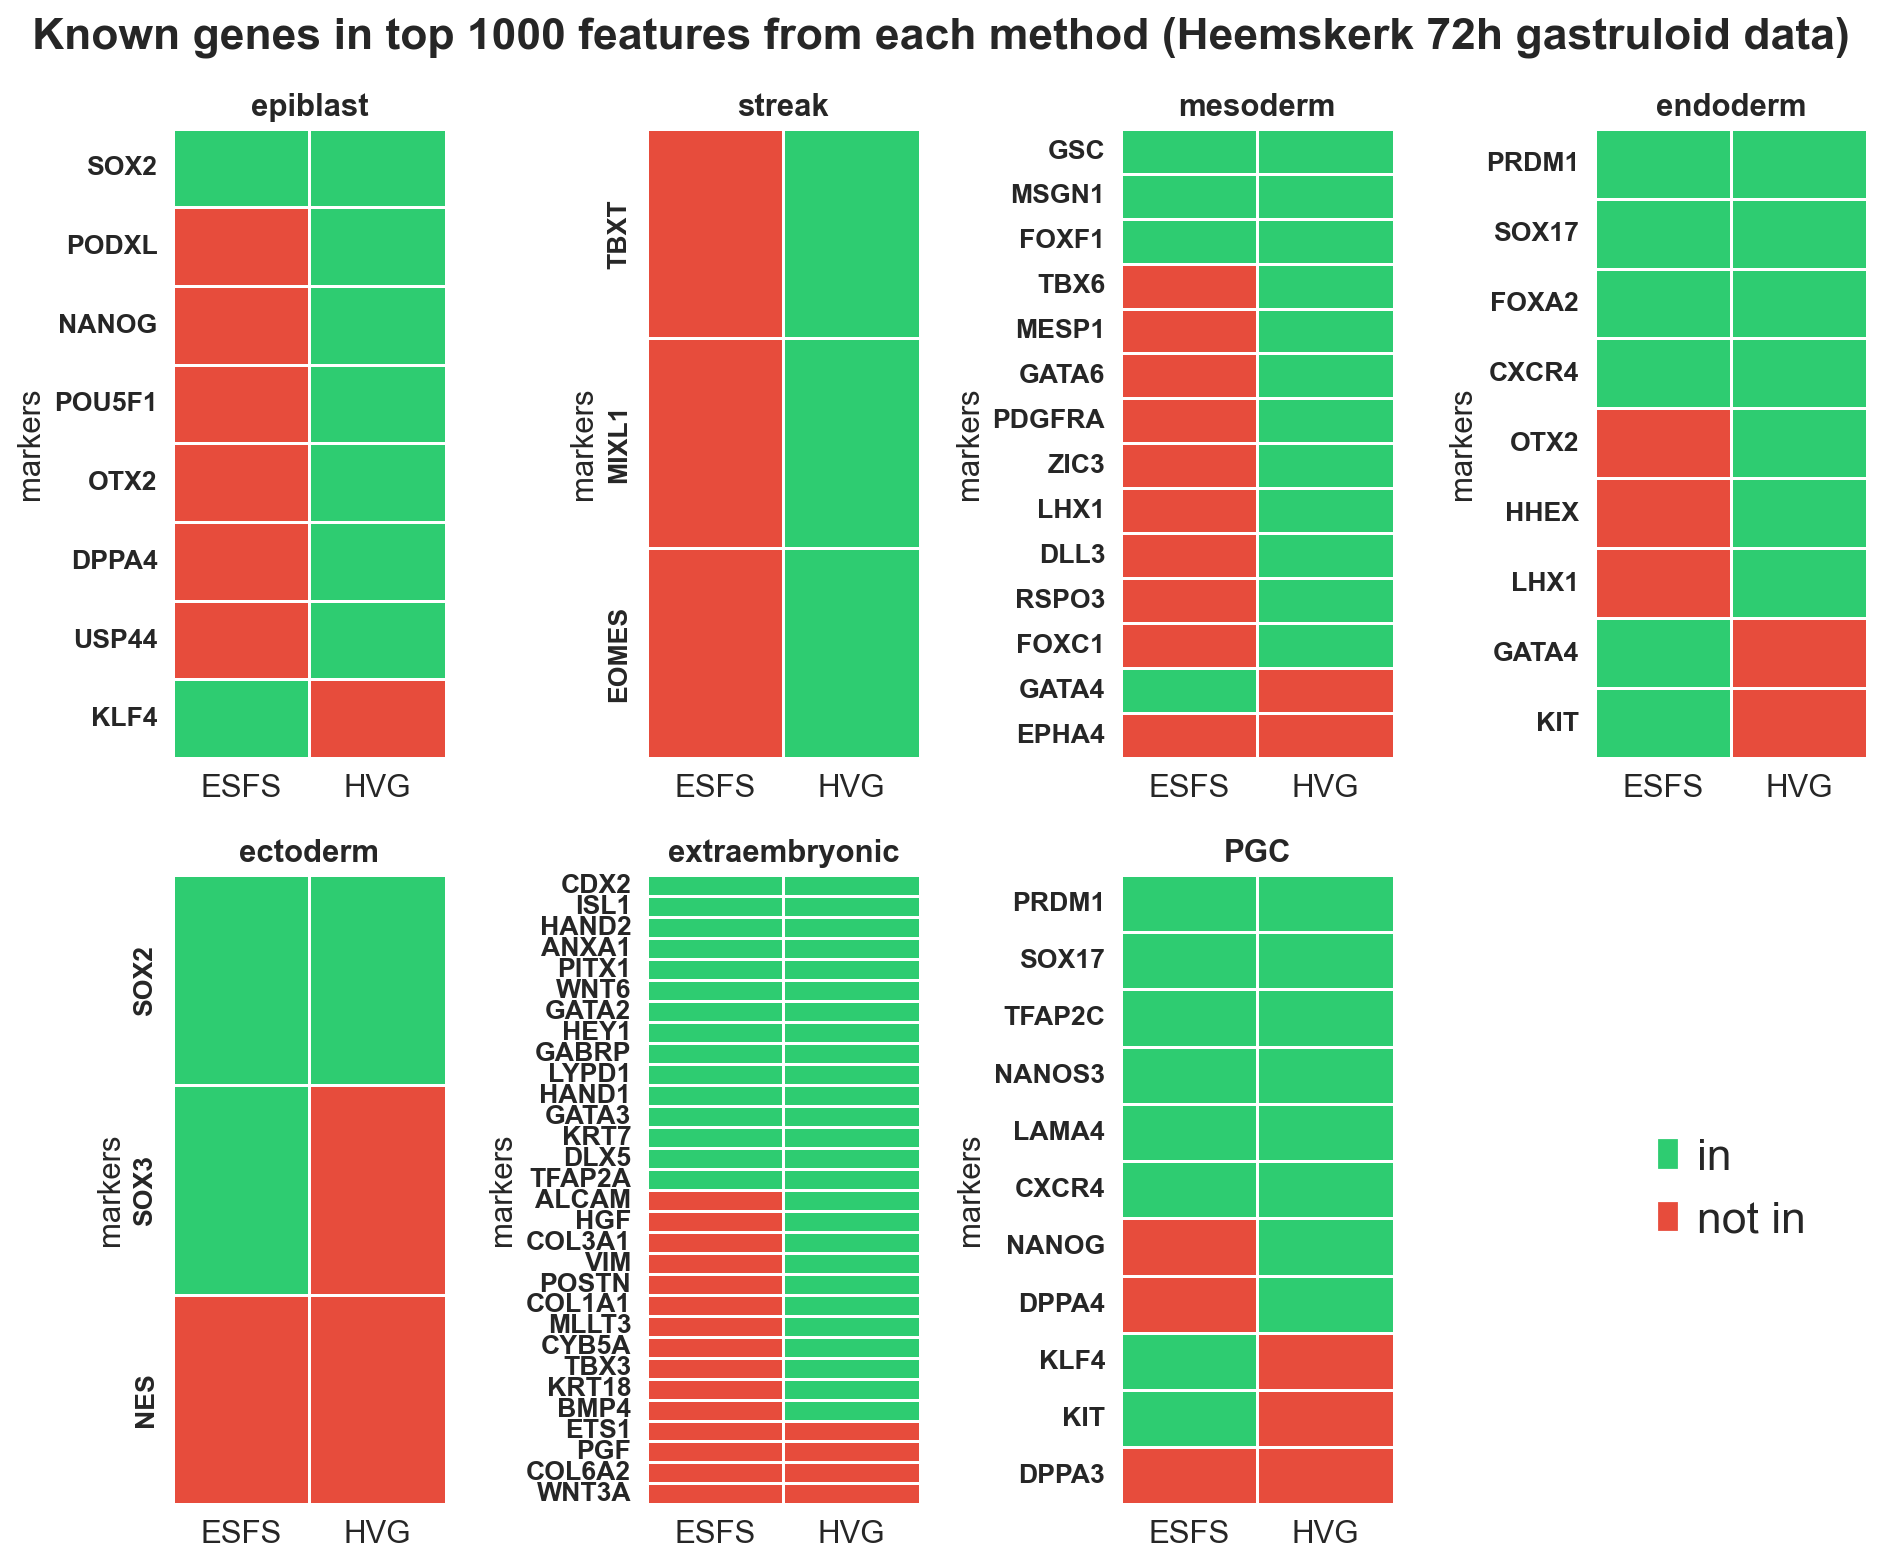

In [113]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

sns.set_style("white")
categories = {
    "epiblast": epiblast,
    "streak": streak,
    "mesoderm": mesoderm,
    "endoderm": endoderm,
    "ectoderm": ectoderm,
    "extraembryonic": extraembryonic,
    "PGC": PGC,
}

top_n = 1000

cat_dfs = {}
for cat, symbols in categories.items():
    patterns = ["^" + g + "($| )" for g in symbols]
    matched = []
    for pattern, symbol in zip(patterns, symbols):
        hits = adata_heemskerk_72h.var_names[
            adata_heemskerk_72h.var_names.str.contains(pattern, regex=True)
        ]
        for h in hits:
            matched.append({"gene": h, "symbol": symbol})
    if not matched:
        continue
    df = pd.DataFrame(matched).drop_duplicates(subset="gene").set_index("gene")
    df = df.join(adata_heemskerk_72h.var[["ES_Rank", "highly_variable_rank"]])
    df["in_esfs"] = df["ES_Rank"].notna() & (df["ES_Rank"] <= top_n)
    df["in_hvg"] = df["highly_variable_rank"].notna() & (
        df["highly_variable_rank"] <= top_n
    )
    cat_dfs[cat] = df

ncols = 4
nrows = int(np.ceil(len(cat_dfs) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(12, nrows * 5))
axes = axes.flatten()

for i, (cat, df) in enumerate(cat_dfs.items()):
    heatmap_data = pd.DataFrame(
        {
            "ESFS": df["in_esfs"].__array__().astype(int),
            "HVG": df["in_hvg"].__array__().astype(int),
        },
        index=df["symbol"],
    )
    heatmap_data["sort_key"] = heatmap_data.sum(axis=1) * 10 + heatmap_data["HVG"]
    heatmap_data = heatmap_data.sort_values("sort_key", ascending=False).drop(
        columns="sort_key"
    )

    sns.heatmap(
        heatmap_data,
        cmap=["#e74c3c", "#2ecc71"],
        linewidths=0.5,
        cbar=False,
        xticklabels=True,
        yticklabels=True,
        ax=axes[i],
    )
    axes[i].set_yticklabels(axes[i].get_yticklabels(), fontsize=12, fontweight="bold")
    axes[i].set_title(cat, fontweight="bold")
    axes[i].set_ylabel("markers")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")
fig.suptitle(
    f"Known genes in top {top_n} features from each method (Heemskerk 72h gastruloid data)",
    fontsize=20,
    fontweight="bold",
)

legend_handles = [
    Patch(facecolor="#2ecc71", label="in"),
    Patch(facecolor="#e74c3c", label="not in"),
]
axes[-1].legend(handles=legend_handles, loc="center", fontsize=20, frameon=False)
plt.tight_layout()
plt.savefig("esfs_vs_hvg.png", dpi=300, bbox_inches="tight")